# Unsupervised Learning II - Dimension Reduction

## References

Chapter 12.5.1, [ISLP] An Introduction to Statistical Learning - with Applications in Python. Free access to download the book: https://www.statlearning.com/

<a target="_blank" href="https://colab.research.google.com/github/cspun/MLF/blob/JNB/unsup-II.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.datasets import get_rdataset
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from ISLP import load_data

We also collect the new imports
needed for this lab.

In [2]:
from sklearn.cluster import \
     (KMeans,
      AgglomerativeClustering)
from scipy.cluster.hierarchy import \
     (dendrogram,
      cut_tree)
from ISLP.cluster import compute_linkage

## Principal Components Analysis
We perform PCA on  `USArrests`, a data set in the `R` computing environment. We retrieve the data using `get_rdataset()`, which can fetch data from many standard `R` packages.

The rows of the data set contain the 50 states, in alphabetical order.

In [3]:
USArrests = get_rdataset('USArrests').data
USArrests

,Murder,Assault,UrbanPop,Rape
rownames,,,,
Alabama,13.2,236,58,21.2
Alaska,10.0,263,48,44.5
Arizona,8.1,294,80,31.0
Arkansas,8.8,190,50,19.5
California,9.0,276,91,40.6
Colorado,7.9,204,78,38.7
Connecticut,3.3,110,77,11.1
Delaware,5.9,238,72,15.8
Florida,15.4,335,80,31.9


The columns of the data set contain the four variables.

In [4]:
USArrests.columns

Index(['Murder', 'Assault', 'UrbanPop', 'Rape'], dtype='object')

We first briefly examine the data. We notice that the variables have vastly different means.

In [5]:
USArrests.mean()

Murder        7.788
Assault     170.760
UrbanPop     65.540
Rape         21.232
dtype: float64

Dataframes have several useful methods for computing
column-wise summaries. We can also examine the
variance of the four variables using the `var()`  method.

In [6]:
USArrests.var()

Murder        18.970465
Assault     6945.165714
UrbanPop     209.518776
Rape          87.729159
dtype: float64

Not surprisingly, the variables also have vastly different variances.
The `UrbanPop` variable measures the percentage of the population
in each state living in an urban area, which is not a comparable
number to the number of rapes in each state per 100,000 individuals.
PCA looks for derived variables that account for most of the variance in the data set.
If we do not scale the variables before performing PCA, then the principal components
would mostly be driven by the
`Assault` variable, since it has by far the largest
variance.  So if the variables are measured in different units or vary widely in scale, it is recommended to standardize the variables to have standard deviation one before performing PCA.
Typically we set the means to zero as well.

This scaling can be done via the `StandardScaler()` transform imported above. We first `fit` the
scaler, which computes the necessary means and standard
deviations and then apply it to our data using the
`transform` method. As before, we combine these steps using the `fit_transform()` method.


In [7]:
scaler = StandardScaler(with_std=True, with_mean=True)
USArrests_scaled = scaler.fit_transform(USArrests)

Having scaled the data, we can then
perform principal components analysis using the `PCA()` transform
from the `sklearn.decomposition` package.

In [8]:
pcaUS = PCA()

(By default, the `PCA()`  transform centers the variables to have
mean zero though it does not scale them.) The transform `pcaUS`
can be used to find the PCA
`scores` returned by `fit()`. Once the `fit` method has been called, the `pcaUS` object also contains a number of useful quantities.

In [9]:
pcaUS.fit(USArrests_scaled)

PCA()

After fitting, the `mean_` attribute corresponds to the means
of the variables. In this case, since we centered and scaled the data with
`scaler()` the means will all be 0.

In [10]:
pcaUS.mean_

array([-7.10542736e-17,  1.38777878e-16, -4.39648318e-16,  8.59312621e-16])

The scores can be computed using the `transform()` method
of `pcaUS` after it has been fit.

In [11]:
scores = pcaUS.transform(USArrests_scaled)

We will plot these scores a bit further down.
The `components_` attribute provides the principal component loadings:
each row of `pcaUS.components_` contains the corresponding
principal component loading vector.


In [12]:
pcaUS.components_ 

array([[ 0.53589947,  0.58318363,  0.27819087,  0.54343209],
       [-0.41818087, -0.1879856 ,  0.87280619,  0.16731864],
       [-0.34123273, -0.26814843, -0.37801579,  0.81777791],
       [-0.6492278 ,  0.74340748, -0.13387773, -0.08902432]])

The `biplot`  is a common visualization method used with
PCA. It is not built in as a standard
part of `sklearn`, though there are python
packages that do produce such plots. Here we
make a simple biplot manually.

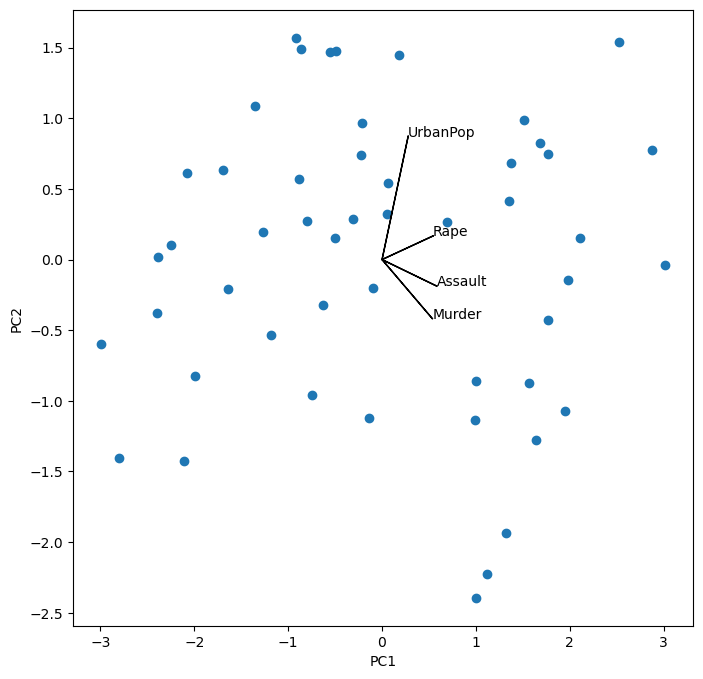

In [13]:
i, j = 0, 1 # which components
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaUS.components_.shape[1]):
    ax.arrow(0, 0, pcaUS.components_[i,k], pcaUS.components_[j,k])
    ax.text(pcaUS.components_[i,k],
            pcaUS.components_[j,k],
            USArrests.columns[k])

Recall that the principal components are only unique up to a sign change, so we can reproduce that figure by flipping the signs of the second set of scores and loadings. We also increase the length of the arrows to emphasize the loadings.

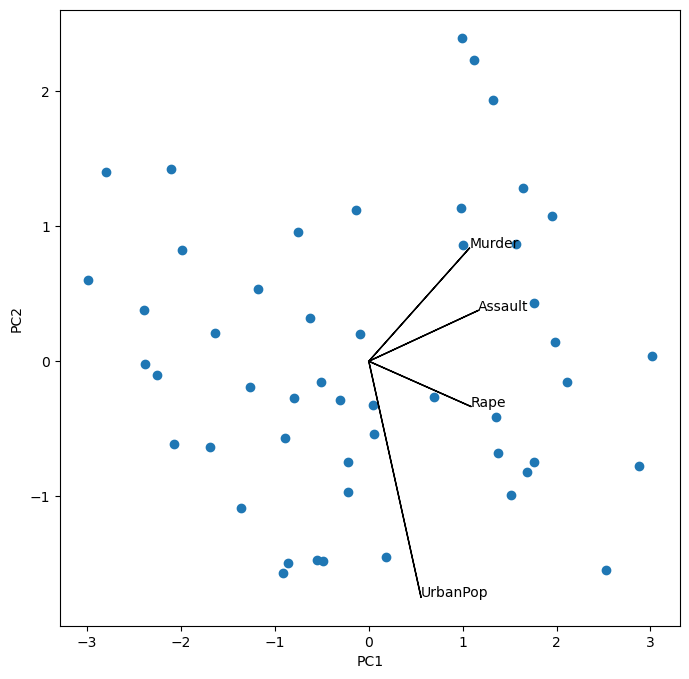

In [14]:
scale_arrow = s_ = 2
scores[:,1] *= -1
pcaUS.components_[1] *= -1 # flip the y-axis
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
ax.scatter(scores[:,0], scores[:,1])
ax.set_xlabel('PC%d' % (i+1))
ax.set_ylabel('PC%d' % (j+1))
for k in range(pcaUS.components_.shape[1]):
    ax.arrow(0, 0, s_*pcaUS.components_[i,k], s_*pcaUS.components_[j,k])
    ax.text(s_*pcaUS.components_[i,k],
            s_*pcaUS.components_[j,k],
            USArrests.columns[k])

The standard deviations of the principal component scores are as follows:

In [15]:
scores.std(0, ddof=1)

array([1.5908673 , 1.00496987, 0.6031915 , 0.4206774 ])

The variance of each score can be extracted directly from the `pcaUS` object via
the `explained_variance_` attribute.

In [16]:
pcaUS.explained_variance_

array([2.53085875, 1.00996444, 0.36383998, 0.17696948])

The proportion of variance explained by each principal 
component (PVE) is stored as `explained_variance_ratio_`:

In [17]:
pcaUS.explained_variance_ratio_

array([0.62006039, 0.24744129, 0.0891408 , 0.04335752])

We see that the first principal component explains 62.0% of the
variance in the data, the next principal component explains 24.7%
of the variance, and so forth.
We can plot the PVE explained by each component, as well as the cumulative PVE. We first
plot the proportion of variance explained.

In [18]:
%%capture
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
ticks = np.arange(pcaUS.n_components_)+1
ax = axes[0]
ax.plot(ticks,
        pcaUS.explained_variance_ratio_,
        marker='o')
ax.set_xlabel('Principal Component');
ax.set_ylabel('Proportion of Variance Explained')
ax.set_ylim([0,1])
ax.set_xticks(ticks)

Notice the use of `%%capture`, which suppresses the displaying of the partially completed figure.

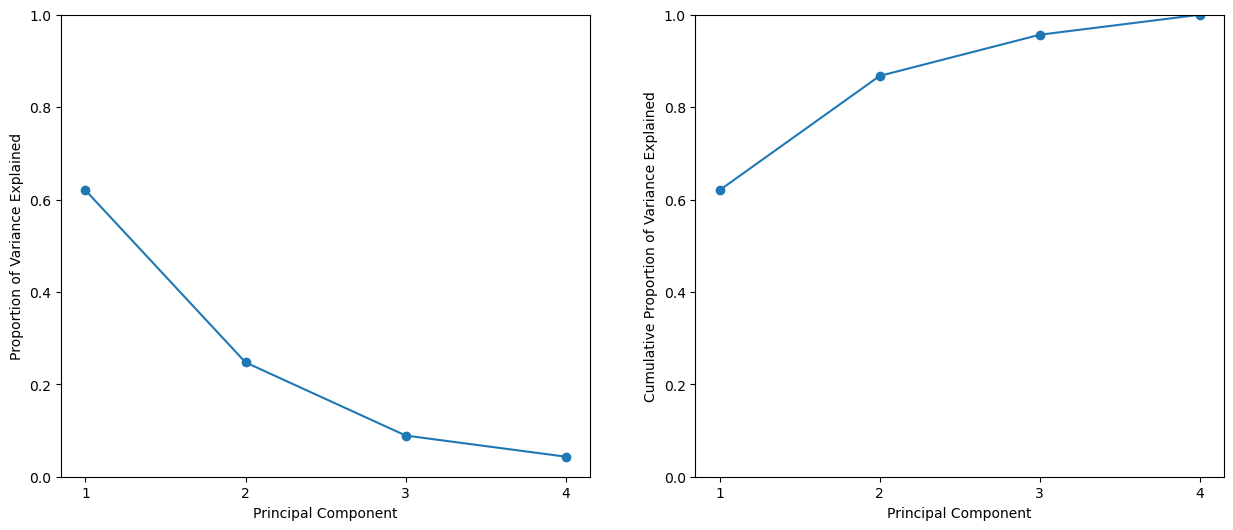

In [19]:
ax = axes[1]
ax.plot(ticks,
        pcaUS.explained_variance_ratio_.cumsum(),
        marker='o')
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative Proportion of Variance Explained')
ax.set_ylim([0, 1])
ax.set_xticks(ticks)
fig

Note that the method `cumsum()`   computes the cumulative sum of the elements of a numeric vector.

On a related note, one can verify the PCA results using eigendecomposition:

In [20]:
Cov_USArrests_scaled = pd.DataFrame(USArrests_scaled).cov()
eigenvalues, eigenvectors = np.linalg.eig(Cov_USArrests_scaled)
print("Eigenvalues:", eigenvalues)
print("Eigenvectors:\n", eigenvectors)

Eigenvalues: [2.53085875 1.00996444 0.17696948 0.36383998]
Eigenvectors:
 [[ 0.53589947  0.41818087  0.6492278  -0.34123273]
 [ 0.58318363  0.1879856  -0.74340748 -0.26814843]
 [ 0.27819087 -0.87280619  0.13387773 -0.37801579]
 [ 0.54343209 -0.16731864  0.08902432  0.81777791]]


## PCA on the NCI60 Data
We illustrate the PCA on the `NCI` cancer cell line microarray data, which consists of 6,830 gene expression measurements on 64 cancer cell lines.

In [21]:
NCI60 = load_data('NCI60')
nci_labs = NCI60['labels']
nci_data = NCI60['data']

We first perform PCA on the data after scaling the variables (genes) to have standard deviation one, although one could reasonably argue that it is better not to scale the genes.

In [22]:
scaler = StandardScaler()
nci_scaled = scaler.fit_transform(nci_data)
nci_pca = PCA()
nci_scores = nci_pca.fit_transform(nci_scaled)

We now  plot the first few principal component score vectors, in order to visualize the data. The observations (cell lines) corresponding to a given cancer type will be plotted in the same color, so that we can see to what extent the observations within a cancer type are similar to each other. We first create a simple function that assigns a distinct color to each element of a numeric vector. The function will be used to assign a  color to each of the 64 cell lines, based on the cancer type to which it corresponds.

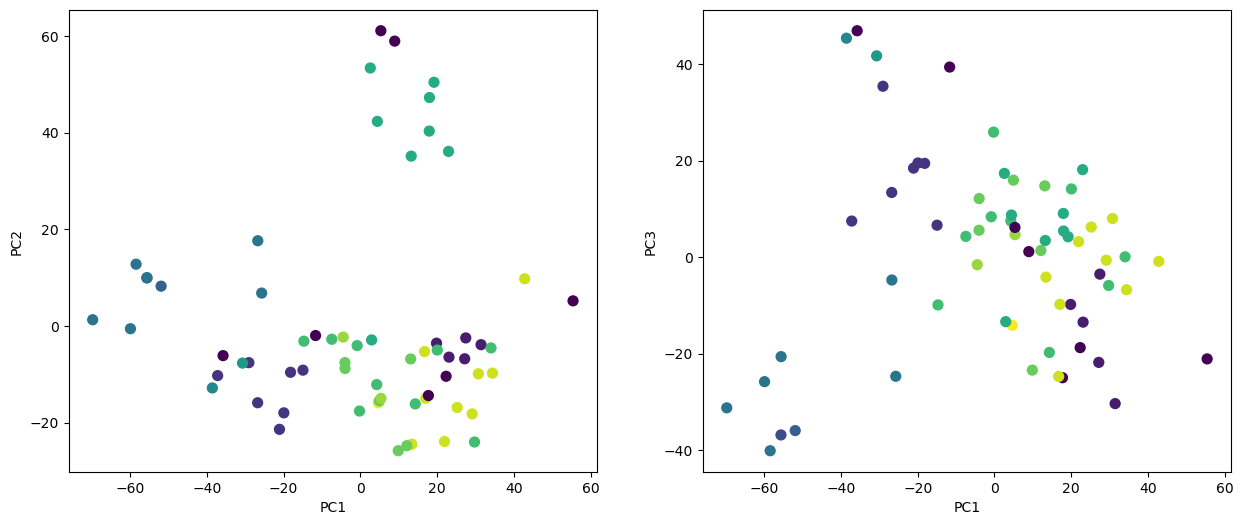

In [23]:
cancer_types = list(np.unique(nci_labs))
nci_groups = np.array([cancer_types.index(lab)
                       for lab in nci_labs.values])
fig, axes = plt.subplots(1, 2, figsize=(15,6))
ax = axes[0]
ax.scatter(nci_scores[:,0],
           nci_scores[:,1],
           c=nci_groups,
           marker='o',
           s=50)
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax = axes[1]
ax.scatter(nci_scores[:,0],
           nci_scores[:,2],
           c=nci_groups,
           marker='o',
           s=50)
ax.set_xlabel('PC1'); ax.set_ylabel('PC3');

On the whole, cell lines corresponding to a single cancer type do tend to
have similar values on the first few principal component score
vectors. This indicates that cell lines from the same cancer type tend
to have pretty similar gene expression levels.


    

We can also plot the percent variance
explained by the principal components as well as the cumulative percent variance explained.
This is similar to the plots we made earlier for the `USArrests` data.

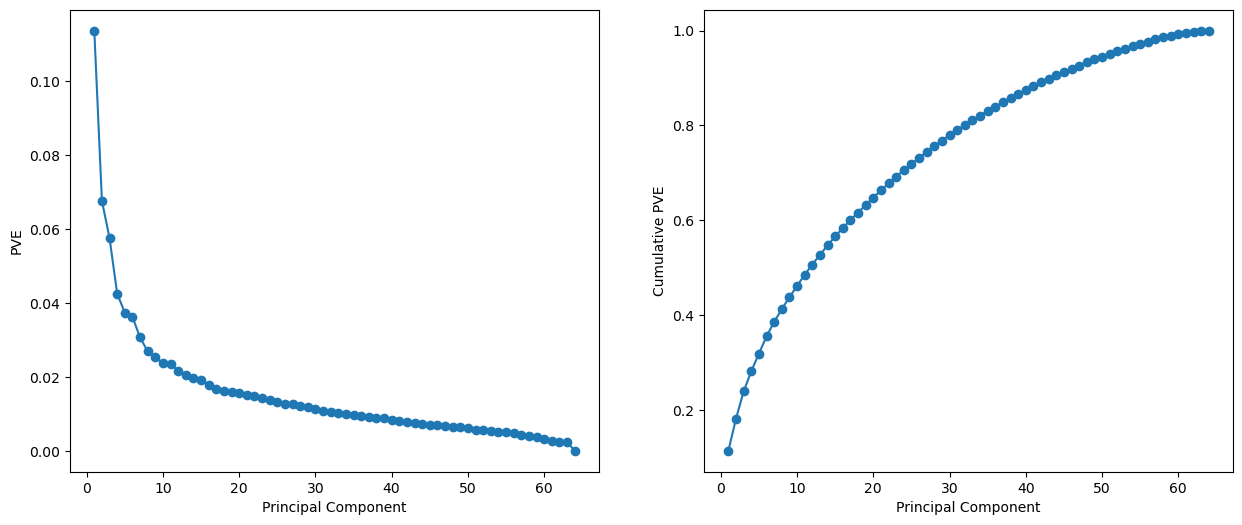

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(15,6))
ax = axes[0]
ticks = np.arange(nci_pca.n_components_)+1
ax.plot(ticks,
        nci_pca.explained_variance_ratio_,
        marker='o')
ax.set_xlabel('Principal Component');
ax.set_ylabel('PVE')
ax = axes[1]
ax.plot(ticks,
        nci_pca.explained_variance_ratio_.cumsum(),
        marker='o');
ax.set_xlabel('Principal Component')
ax.set_ylabel('Cumulative PVE');

We see that together, the first seven principal components explain around 40% of the variance in the data. This is not a huge amount of the variance. However, looking at the scree plot, we see that while each of the first seven principal components explain a substantial amount of variance, there is a marked decrease in the variance explained by further principal components. That is, there is an *elbow*  in the plot after approximately the seventh principal component.  This suggests that there may be little benefit to examining more than seven or so principal components (though even examining seven principal components may be difficult).

Rather than performing hierarchical clustering on the entire data matrix, we can also perform hierarchical clustering on the first few principal component score vectors, regarding these first few components as a less noisy version of the data.
 
 



In [25]:
HClust = AgglomerativeClustering
hc_comp = HClust(distance_threshold=0,
                 n_clusters=None,
                 linkage='complete')

In [26]:
cargs = {'color_threshold':-np.inf,
         'above_threshold_color':'black'}

In [27]:
def plot_nci(linkage, ax, cut=-np.inf):
    cargs = {'above_threshold_color':'black',
             'color_threshold':cut}
    hc = HClust(n_clusters=None,
                distance_threshold=0,
                linkage=linkage.lower()).fit(nci_scaled)
    linkage_ = compute_linkage(hc)
    dendrogram(linkage_,
               ax=ax,
               labels=np.asarray(nci_labs),
               leaf_font_size=10,
               **cargs)
    ax.set_title('%s Linkage' % linkage)
    return hc

Complete-PCA,0,1,2,3
label,,,,
BREAST,0,5,0,2
CNS,2,3,0,0
COLON,7,0,0,0
K562A-repro,0,0,1,0
K562B-repro,0,0,1,0
LEUKEMIA,2,0,4,0
MCF7A-repro,0,0,0,1
MCF7D-repro,0,0,0,1
MELANOMA,1,7,0,0


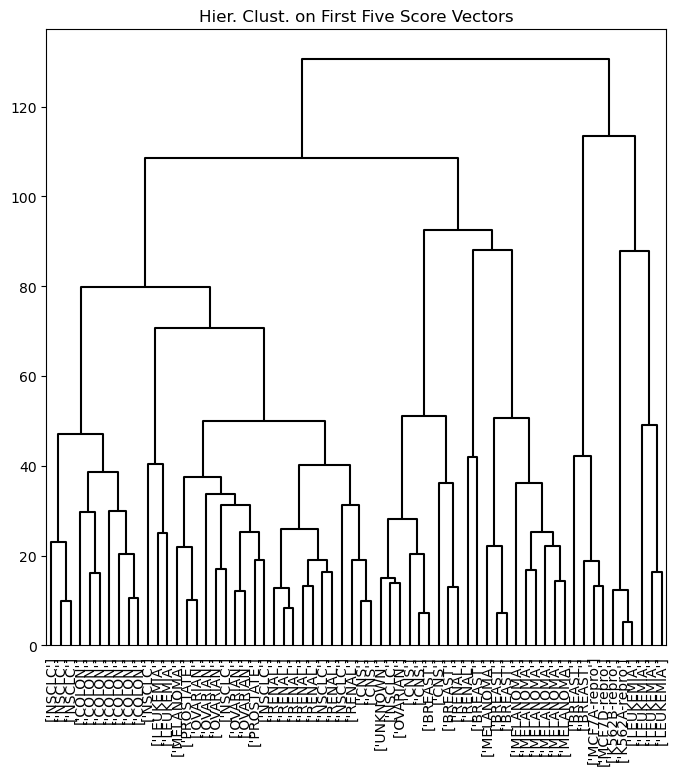

In [28]:
hc_pca = HClust(n_clusters=None,
                distance_threshold=0,
                linkage='complete'
                ).fit(nci_scores[:,:5])
linkage_pca = compute_linkage(hc_pca)
fig, ax = plt.subplots(figsize=(8,8))
dendrogram(linkage_pca,
           labels=np.asarray(nci_labs),
           leaf_font_size=10,
           ax=ax,
           **cargs)
ax.set_title("Hier. Clust. on First Five Score Vectors")
pca_labels = pd.Series(cut_tree(linkage_pca,
                                n_clusters=4).reshape(-1),
                       name='Complete-PCA')
pd.crosstab(nci_labs['label'], pca_labels)

Not surprisingly, these results are different from the ones that we obtained when we performed hierarchical clustering on the full data set:

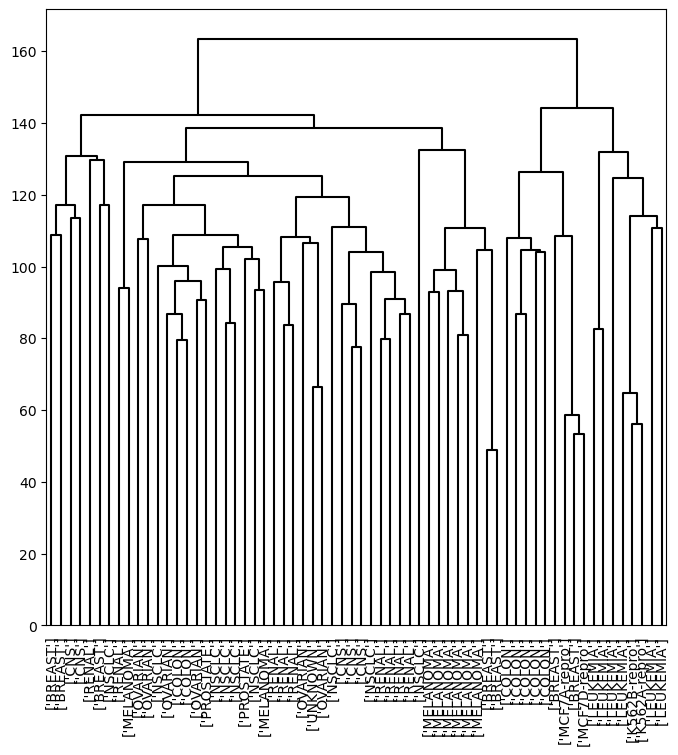

In [29]:
HClust = AgglomerativeClustering
hc_comp = HClust(distance_threshold=0,
                 n_clusters=None,
                 linkage='complete')
hc_comp.fit(nci_scaled)
linkage_comp = compute_linkage(hc_comp)
fig, ax = plt.subplots(1, 1, figsize=(8, 8))
dendrogram(linkage_comp,
           labels=np.asarray(nci_labs),
           leaf_font_size=10,
           ax=ax,
           **cargs);

Sometimes performing clustering on the first few principal component score vectors can give better results than performing clustering on the full data. In this situation, we might view the principal component step as one of denoising the data. We could also perform $K$-means clustering on the first few principal component score vectors rather than the full data set.